In [64]:
""" Compare against pore water chemistry data of Natalie/Verity
Measurements depths are relative to hollow surface"""
import pandas as pd
import numpy as np
import os
from datetime import datetime
from utils.analysis import vert_interp
from utils.constants import chamber_levels_complete, chamber_list_complete_dict
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
from glob import glob
import xarray as xr

chambers_ordered = {
    'amb': ['06', '20', '13', '08', '17'], 
    'elev': ['19', '11', '04', '16', '10']
}
xticklabels = ['0 amb', '2.25 amb','4.5 amb', '6.75 amb', '9 amb', 
               '0 elev', '2.25 elev', '4.5 elev', '6.75 elev', '9 elev']

# which depth of observation to look at, pick from depth_list
depth_list = ['0.0', '0.3', '0.5', '1.0', '2.0', '3.0']
DEPTH = 0.3

In [45]:
# Observed dissolved N & P at multiple depths
data = pd.read_csv(
    os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'input', 
                 'SPRUCE_plot_porewater_chemistry_release_20240617.csv'),
    na_values=[-9999, -8888]
)
data['DATE'] = data['DATE'].apply(lambda x: datetime.strptime(str(x), '%Y%m%d'))
data = data.loc[(pd.DatetimeIndex(data['DATE']).year >= 2015) & 
                (~data['PLOT'].isin([2,5,9,14,15,21])), 
                ['PLOT', 'DEPTH', 'DATE', 'NH4', 'NO3', 'SRP', 'TN', 'TP']]
data['PLOT'] = [f'{x:02d}' for x in data['PLOT']]
data['dT'] = [chamber_levels_complete[x][0] for x in data['PLOT']]
data['CO2'] = [chamber_levels_complete[x][1] for x in data['PLOT']]

data['NH4+NO3'] = data['NH4'] + data['NO3']

data = data.loc[np.isclose(data['DEPTH'], DEPTH), :]
data = data.sort_values(by = 'DATE')

if DEPTH == 0.3:
    # apparently there is some outlier
    data.loc[data['PLOT'].isin(['10', '19']) & (data['NH4'] > 1.5)] = np.nan

In [46]:
# Collect modeled dissolved nutrients, layersize
ensemble_id = None
year_range = range(2015, 2022)
plot_list = list(chamber_levels_complete.keys())
prefix_list = ['20231113', '20231113optim', '20240318']

tvec = pd.date_range('2015-01-01', '2021-12-31')
tvec = tvec[(tvec.month != 2) | (tvec.day != 29)]
sims_data = {}

for prefix in prefix_list:
    sims_data[(prefix, 'SMIN_NO3_vr')] = \
        pd.DataFrame(np.nan, 
                    columns = pd.MultiIndex.from_product([['hummock', 'hollow', 'average'],
                                                            plot_list]),
                    index = tvec)
    sims_data[(prefix, 'SMIN_NH4_vr')] = sims_data[(prefix, 'SMIN_NO3_vr')].copy()
    sims_data[(prefix, 'SMINN_vr')] = sims_data[(prefix, 'SMIN_NO3_vr')].copy()
    sims_data[(prefix, 'SOLUTIONP_vr')] = sims_data[(prefix, 'SMIN_NO3_vr')].copy()

    for plot in plot_list:
        if not "UQ" in prefix:
            rundir = os.path.join(os.environ['E3SM_ROOT'], 'output', 
                                f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC', f'spruce_treatments', 
                                f'plot{plot}_US-SPR_ICB20TRCNPRDCTCBC', 'run')
        else:
            rundir = os.path.join(os.environ['E3SM_ROOT'], 'output', 'UQ',
                                f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC', ensemble_id, 
                                f'P{chamber_list_complete_dict[plot]}')

        flist = sorted(glob(rundir + "/*.h1.*.nc"))
        flist = [f for f in flist if \
                int(f.split('/')[-1].split('.')[-2].split('-')[0]) in year_range]
        hr = xr.open_mfdataset(flist)

        for var in ['SMINN_vr', 'SMIN_NH4_vr', 'SMIN_NO3_vr', 'SOLUTIONP_vr']:
            LEVGRND = np.array([0.007100635, 0.027925, 0.06225858, 0.1188651, 0.2121934,
                                0.3660658, 0.6197585, 1.038027, 1.727635, 2.864607, 4.739157,
                                7.829766, 12.92532, 21.32647, 35.17762])
            LEVGRND_I = np.append(np.insert(
                (LEVGRND[1:] + LEVGRND[:-1])*0.5, 0, 0
            ), LEVGRND[-1] + 0.5 * (LEVGRND[-1] - LEVGRND[-2]))
            THICKNESS = np.diff(LEVGRND_I)

            target_nodes = [DEPTH]
            input_nodes = LEVGRND
            target_single_level = True

            for col, colname in enumerate(['hummock', 'hollow']):
                input_data = hr[var][:, :, col].values / hr['H2OSOI'][:, :, col].values

                result = vert_interp(target_nodes, input_nodes, input_data, 
                                    target_single_level)
                sims_data[(prefix, var)].loc[:, (colname, plot)] = result[:, 0]
        hr.close()

    for var in ['SMINN_vr', 'SMIN_NH4_vr', 'SMIN_NO3_vr', 'SOLUTIONP_vr']:
        sims_data[(prefix, var)].loc[:, 'average'] = \
            sims_data[(prefix, var)].loc[:, 'hummock'].values * 0.64 + \
            sims_data[(prefix, var)].loc[:, 'hollow'].values * 0.36

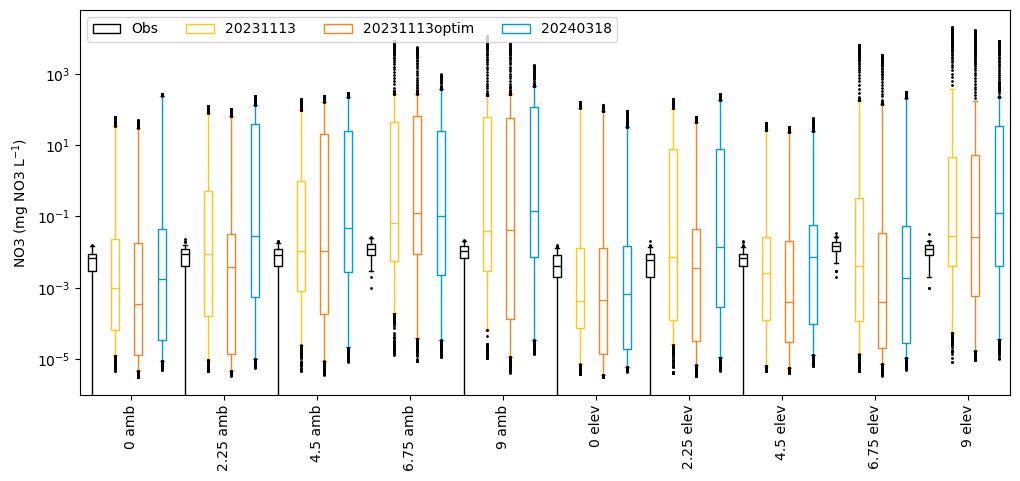

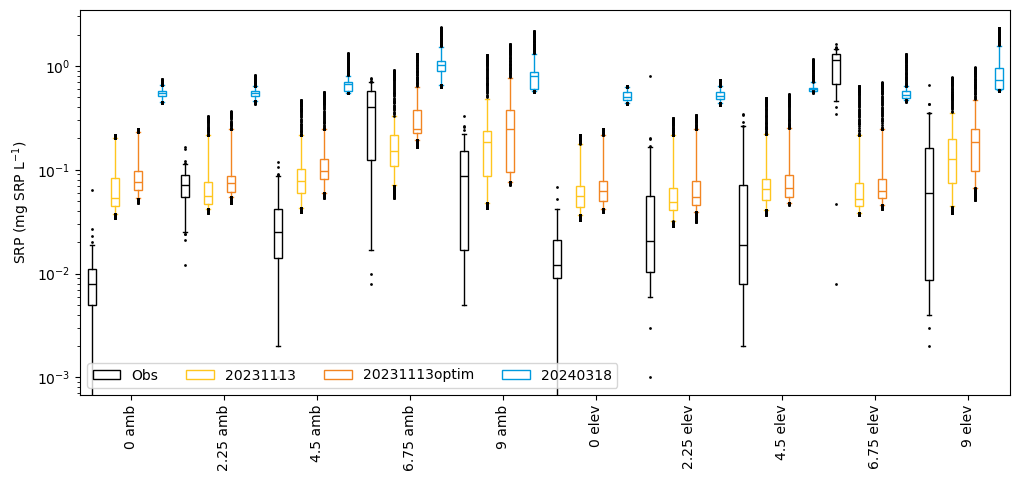

In [47]:
clist = ['k', '#FFC61E', '#F28522', '#009ADE']

for nu, sim_name, obs_name in zip(
    ['N', 'P'], ['SMIN_NO3_vr', 'SOLUTIONP_vr'], ['NO3', 'SRP']
):
    fig, ax = plt.subplots(1, 1, figsize = (12, 5), sharex = True, sharey = True)

    # observed data
    obs_data_var = {k: list(v[obs_name].dropna()) for \
                    k, v in data[['PLOT', obs_name]].groupby('PLOT')}
    for pos, plot in zip( np.arange(0, (1+len(prefix_list)) * len(xticklabels), 
                                    1+len(prefix_list)), 
                          chambers_ordered['amb'] + chambers_ordered['elev'] ):
        bp0 = ax.boxplot(obs_data_var[plot], positions = [pos - 0.18], widths = 0.35,
                         patch_artist = True, flierprops = {'markersize': 1}, 
                         whis = [5, 95])
        for element in ['boxes', 'whiskers', 'fliers', 'means', 'medians', 'caps']:
            plt.setp(bp0[element], color=clist[0])
        for patch in bp0['boxes']:
            patch.set_facecolor('none')
    
    h = [bp0['boxes'][0]]
    hl = ['Obs']

    # growing season simulated data
    for p, prefix in enumerate(prefix_list, 1):
        sims_data_var = sims_data[(prefix, sim_name)]
        sims_data_var = sims_data_var.loc[
            (sims_data_var.index.month >= 3) & (sims_data_var.index.month <= 9), 
            'hollow'].loc[:, chambers_ordered['amb'] + chambers_ordered['elev']]

        bp1 = ax.boxplot(sims_data_var * 1e3,
                         positions = np.arange(p, (1+len(prefix_list)) * len(xticklabels), 
                                               1+len(prefix_list)) - 0.18, 
                         widths = 0.35, patch_artist = True, 
                         whis = [5, 95], 
                         flierprops = {'markersize': 1})

        for element in ['boxes', 'whiskers', 'fliers', 'means', 'medians', 'caps']:
            plt.setp(bp1[element], color=clist[p])
        for patch in bp1['boxes']:
            patch.set_facecolor('none')

        h.append(bp1['boxes'][0])
        hl.append(prefix)

    # 
    ax.set_ylabel(f'{obs_name} (mg {obs_name}' + ' L$^{-1}$)')
    ax.set_xticks(np.arange(1.5, 4*sims_data_var.shape[1], 4))
    ax.set_xticklabels(xticklabels, rotation = 90)
    ax.set_xlabel(None)
    ax.set_yscale('log')

    ax.legend(h, hl, ncol = 4)

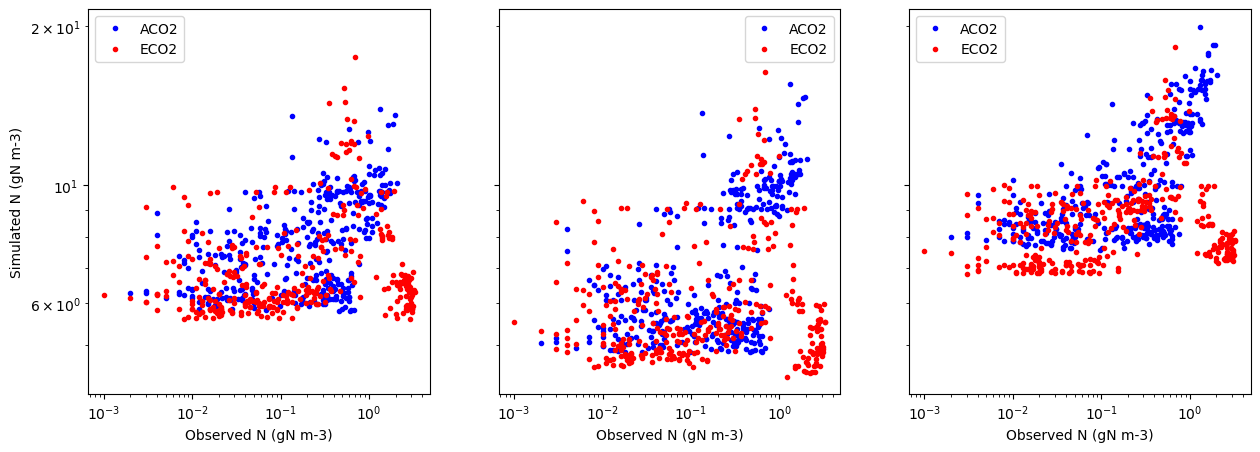

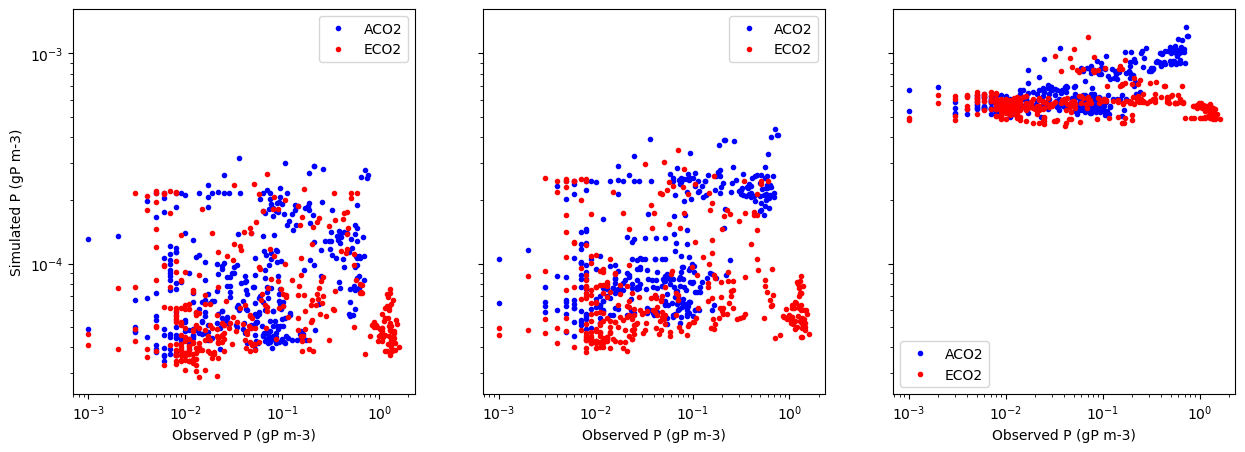

In [51]:
for nu, sim_name, obs_name in zip(
    ['N', 'P'], ['SMINN_vr', 'SOLUTIONP_vr'], ['NH4+NO3', 'SRP']
):
    fig, axes = plt.subplots(1, 3, figsize = (15, 5), sharex = True, sharey = True)

    # observed data
    obs_data_var = data[['PLOT', 'DATE', obs_name]
                        ].set_index(['DATE', 'PLOT']).iloc[:,0].dropna().unstack()

    for p, prefix in enumerate(prefix_list):
        ax = axes.flat[p]

        # growing season simulated data
        sims_data_var = sims_data[(prefix, sim_name)]
        sims_data_var = sims_data_var.loc[:, 'hollow']

        sims_data_matched = pd.DataFrame(np.nan, index = obs_data_var.index, 
                                        columns = obs_data_var.columns)
        for plot in chambers_ordered['amb'] + chambers_ordered['elev']:
            sims_data_matched.loc[:, plot] = \
                sims_data_var.loc[obs_data_var.index, plot]

        # 
        for co2, plot_list, c in zip(['ACO2', 'ECO2'], 
            [chambers_ordered['amb'], chambers_ordered['elev']], 
            ['b', 'r']):
            ax.plot(obs_data_var.loc[:, plot_list].values.reshape(-1), 
                    sims_data_matched.loc[:, plot_list].values.reshape(-1), 
                    label = co2, marker = 'o', lw = 0, color = c, markersize = 3)

        ax.legend()

        ax.set_xlabel(f'Observed {nu} (g{nu} m-3)')
        if p == 0:
            ax.set_ylabel(f'Simulated {nu} (g{nu} m-3)')
        ax.set_xscale('log')
        ax.set_yscale('log')

/tmp/ipykernel_352052/3436334394.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('magma_r')


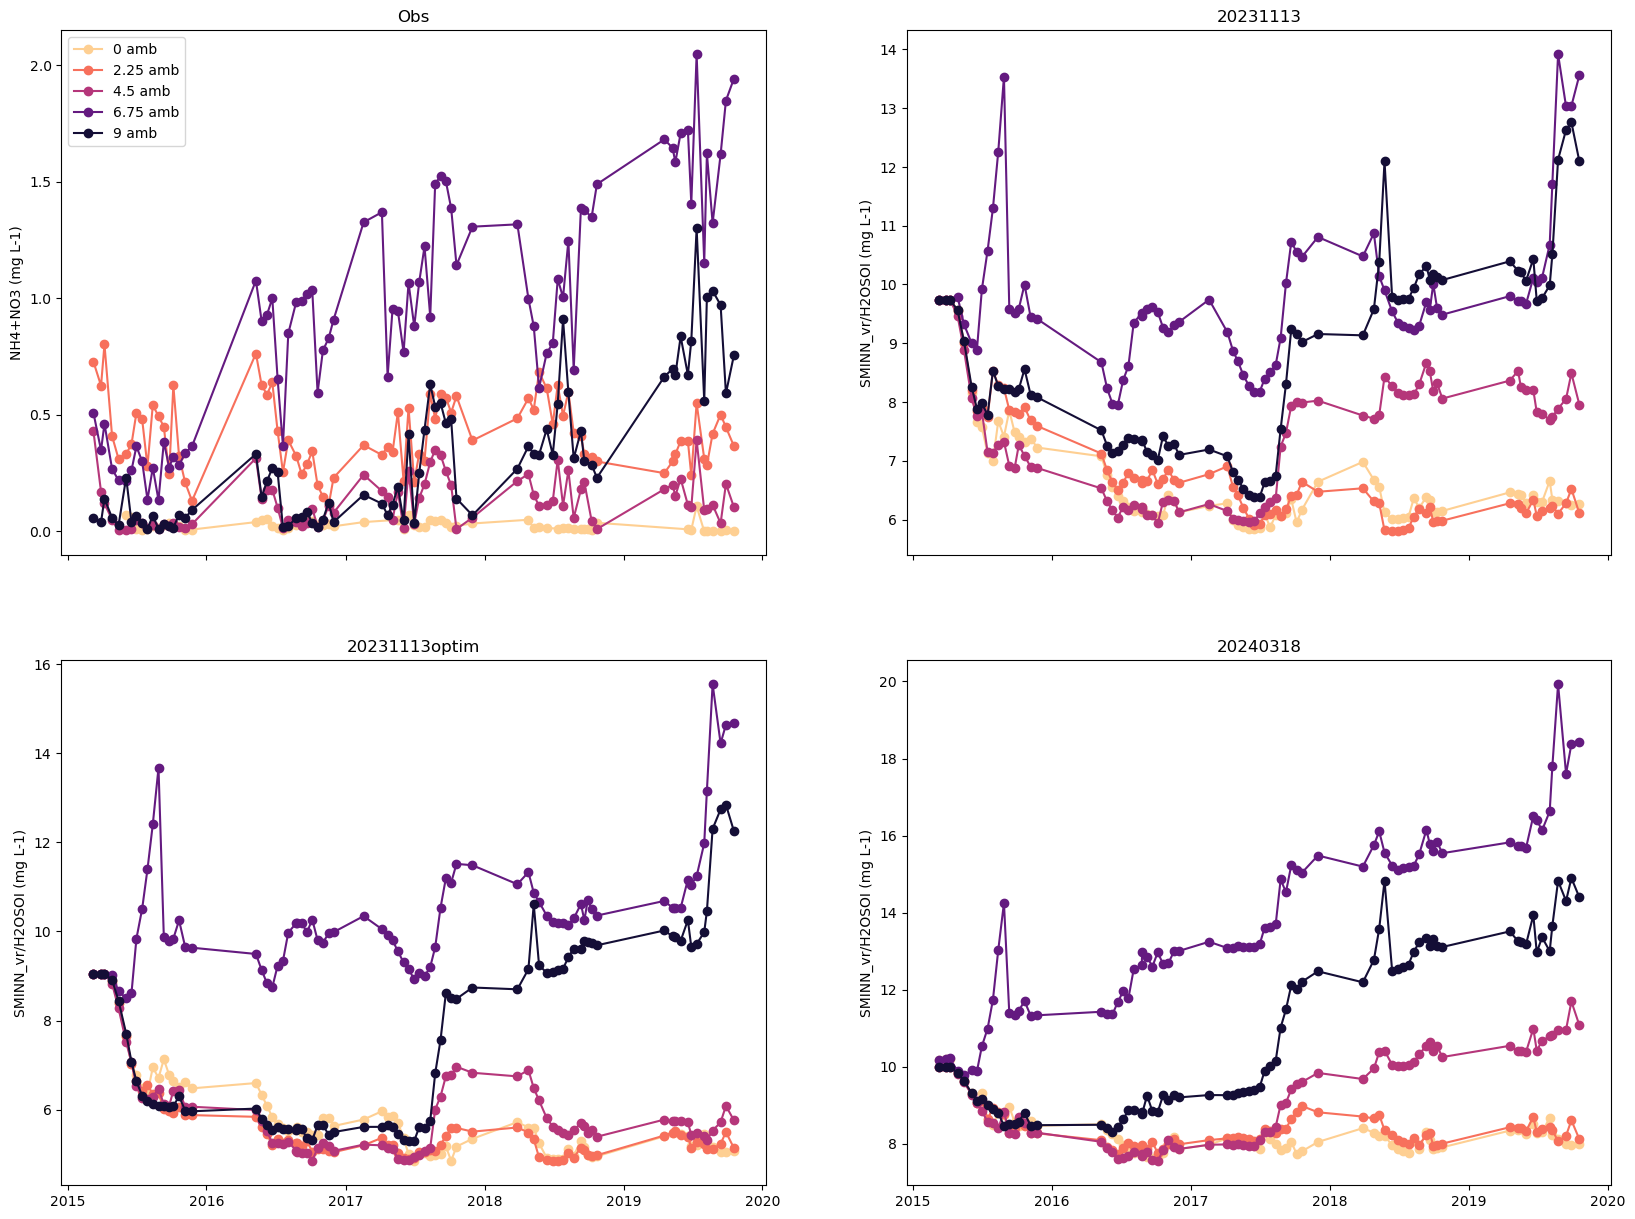

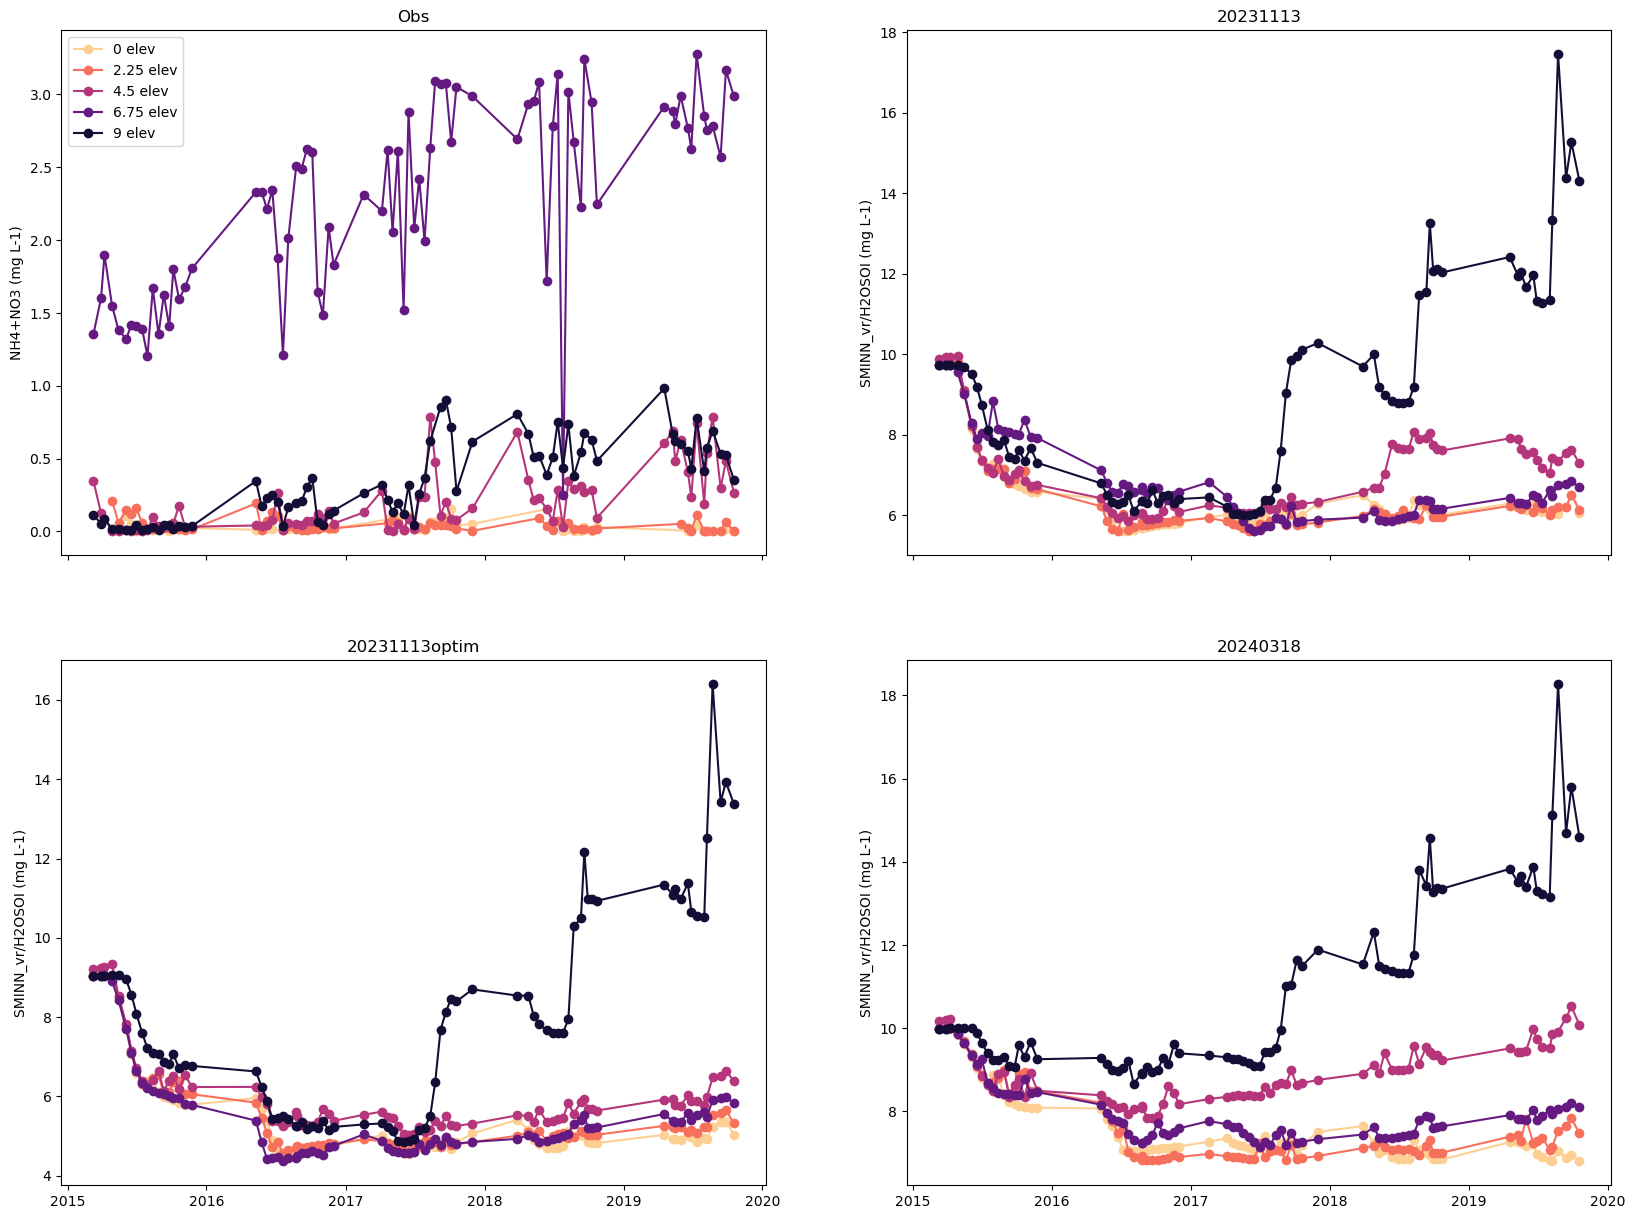

In [87]:
for co2 in ['amb', 'elev']:
    if co2 == 'amb':
        label_list = xticklabels[:5]
    else:
        label_list = xticklabels[5:]

    fig, axes = plt.subplots(2, 2, figsize = (20, 15), sharex = True, sharey = False)

    cmap = get_cmap('magma_r')
    clist = [ cmap((i+0.5) / 5) for i in range(5) ]

    # observation
    ax = axes.flat[0]
    count = 0
    for plot, label in zip(chambers_ordered[co2], label_list):
        ax.plot(data.loc[data['PLOT'] == plot, 'DATE'], 
                data.loc[data['PLOT'] == plot, 'NH4+NO3'], 
                '-o', label = label, color = clist[count])
        count += 1
    ax.legend()
    ax.set_title('Obs')
    ax.set_ylabel('NH4+NO3 (mg L-1)')

    # simulations
    for p, prefix in enumerate(prefix_list, 1):

        # growing season simulated data
        sims_data_var = sims_data[(prefix, 'SMINN_vr')]
        sims_data_var = sims_data_var.loc[:, 'hollow']

        sims_data_matched = pd.DataFrame(np.nan, index = obs_data_var.index, 
                                        columns = obs_data_var.columns)
        for plot in chambers_ordered['amb'] + chambers_ordered['elev']:
            sims_data_matched.loc[:, plot] = \
                sims_data_var.loc[obs_data_var.index, plot]

        ax = axes.flat[p]
        count = 0
        for plot, label in zip(chambers_ordered[co2], label_list):
            ax.plot(sims_data_matched.index, 
                    sims_data_matched.loc[:, plot], 
                    '-o', label = label, color = clist[count])
            count += 1
            ax.set_title(prefix)
            ax.set_ylabel('SMINN_vr/H2OSOI (mg L-1)')

/tmp/ipykernel_352052/2869672798.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('viridis_r')


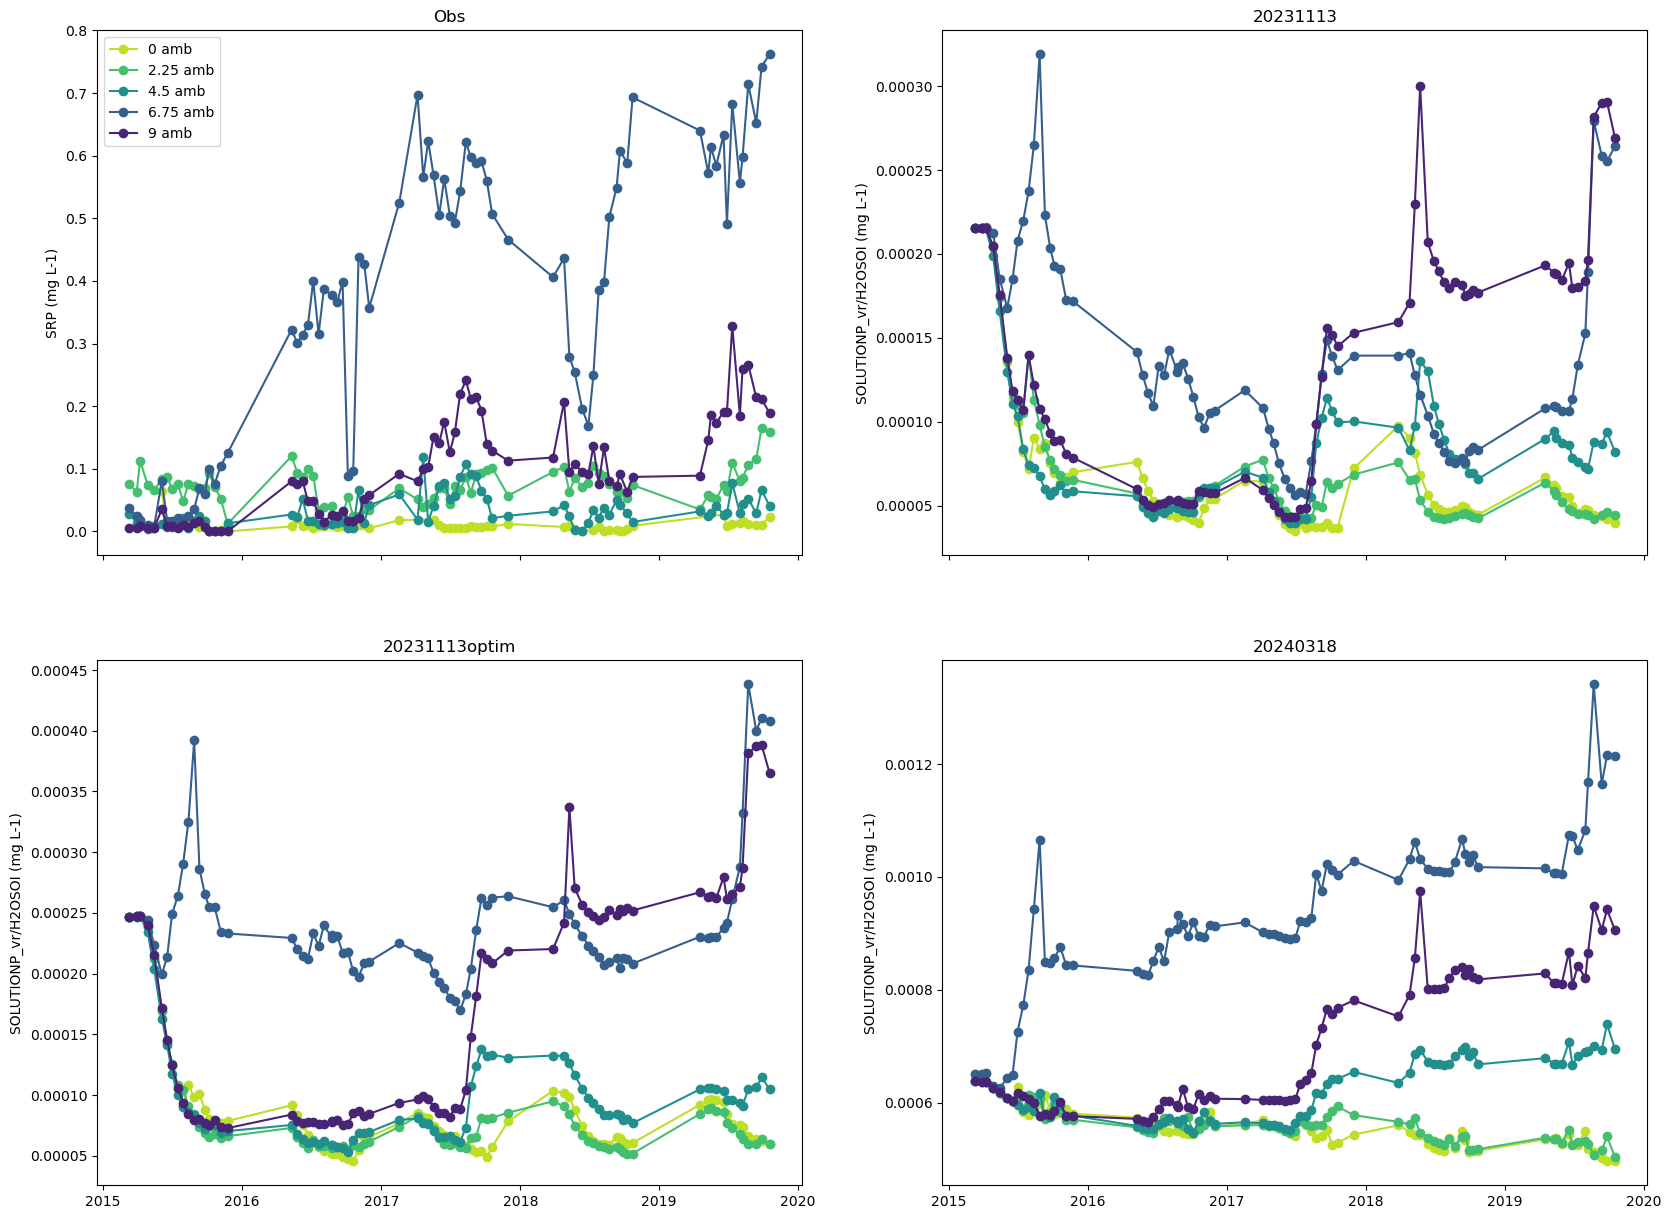

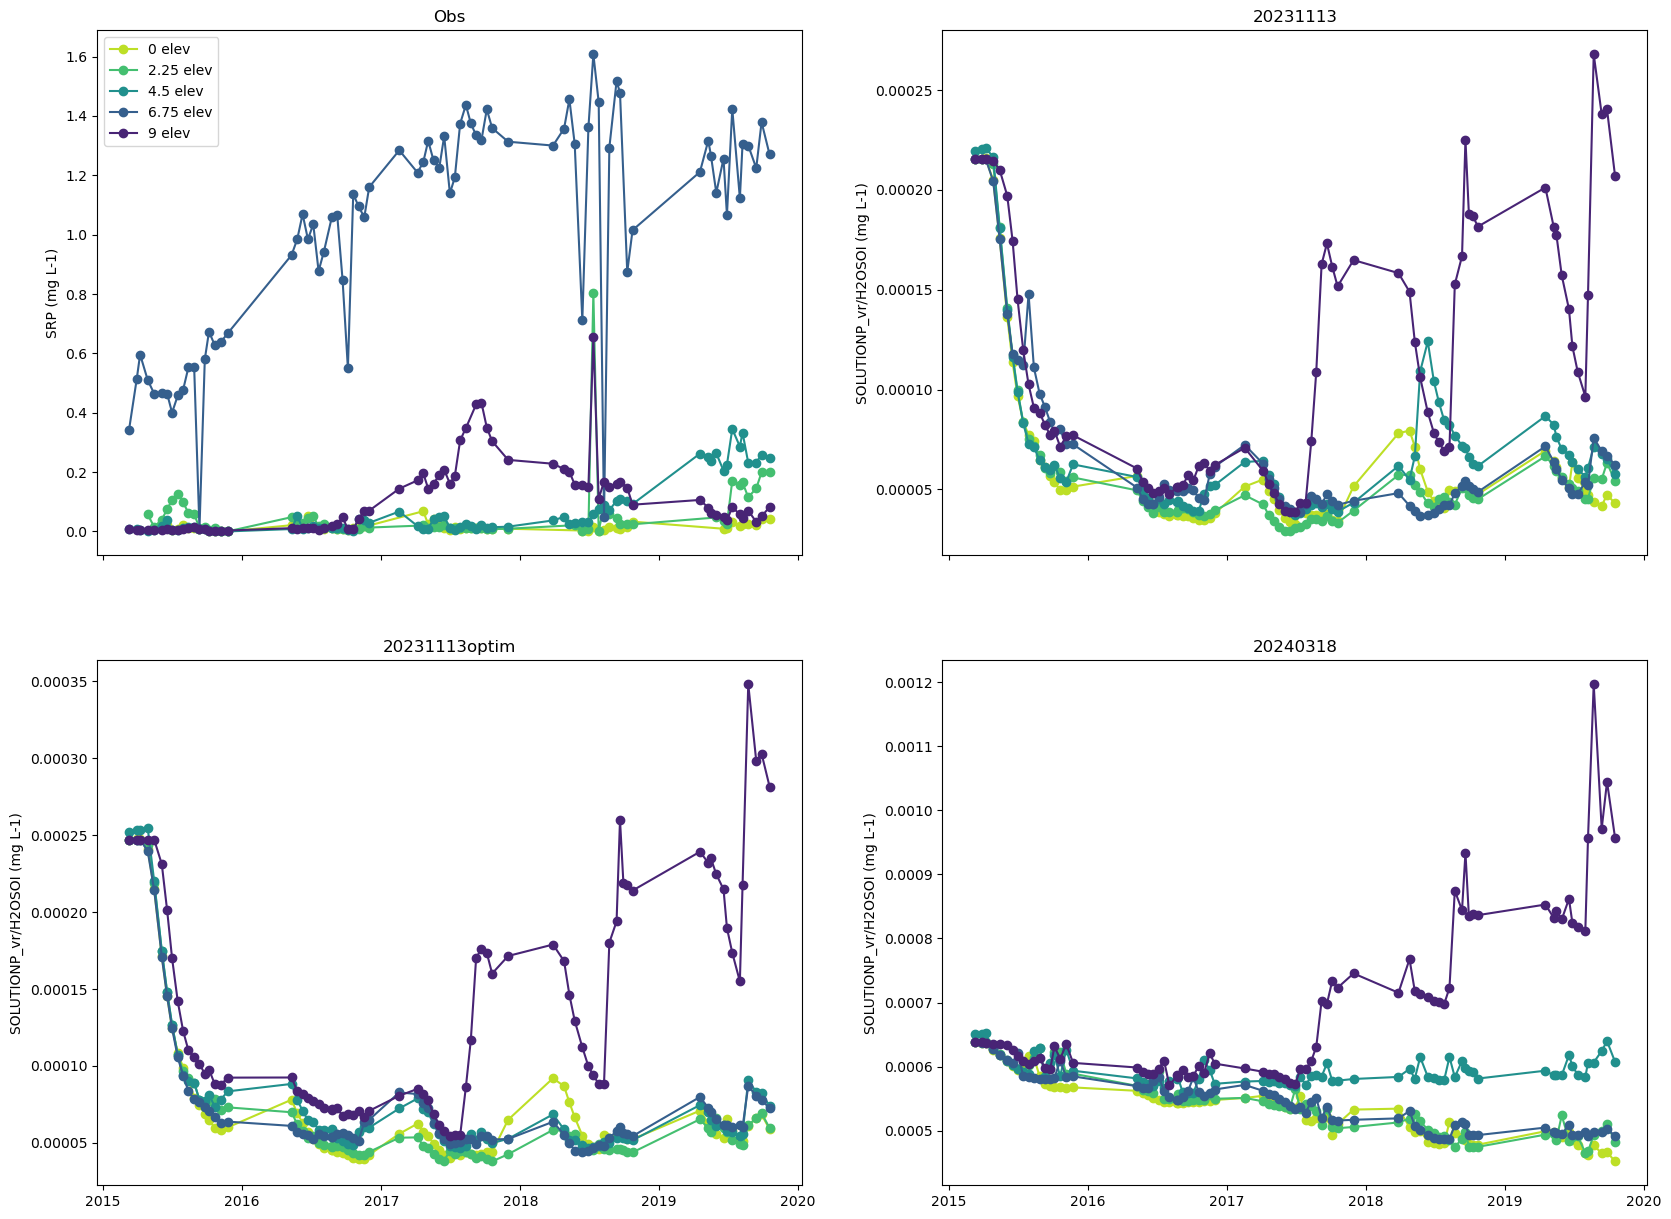

In [89]:
for co2 in ['amb', 'elev']:
    if co2 == 'amb':
        label_list = xticklabels[:5]
    else:
        label_list = xticklabels[5:]

    fig, axes = plt.subplots(2, 2, figsize = (20, 15), sharex = True, sharey = False)

    cmap = get_cmap('viridis_r')
    clist = [ cmap((i+0.5) / 5) for i in range(5) ]

    # observation
    ax = axes.flat[0]
    count = 0
    for plot, label in zip(chambers_ordered[co2], label_list):
        ax.plot(data.loc[data['PLOT'] == plot, 'DATE'], 
                data.loc[data['PLOT'] == plot, 'SRP'], 
                '-o', label = label, color = clist[count])
        count += 1
    ax.legend()
    ax.set_title('Obs')
    ax.set_ylabel('SRP (mg L-1)')

    # simulations
    for p, prefix in enumerate(prefix_list, 1):

        # growing season simulated data
        sims_data_var = sims_data[(prefix, 'SOLUTIONP_vr')]
        sims_data_var = sims_data_var.loc[:, 'hollow']

        sims_data_matched = pd.DataFrame(np.nan, index = obs_data_var.index, 
                                        columns = obs_data_var.columns)
        for plot in chambers_ordered['amb'] + chambers_ordered['elev']:
            sims_data_matched.loc[:, plot] = \
                sims_data_var.loc[obs_data_var.index, plot]

        ax = axes.flat[p]
        count = 0
        for plot, label in zip(chambers_ordered[co2], label_list):
            ax.plot(sims_data_matched.index, 
                    sims_data_matched.loc[:, plot], 
                    '-o', label = label, color = clist[count])
            count += 1
            ax.set_title(prefix)
            ax.set_ylabel('SOLUTIONP_vr/H2OSOI (mg L-1)')